<a href="https://colab.research.google.com/github/listarova-aleksandra/I_to_I/blob/main/lab_4_Data_preprocessing_and_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 'Предобработка и анализ данных'

**В этой лабораторной работе мне необходимо выявить определяющие успешность игры закономерности. Это
позволит сделать ставку на потенциально популярный продукт и спланировать
рекламные кампании.**

**В наборе данных попадается аббревиатура ESRB (Entertainment Software Rating Board) —
это ассоциация, определяющая возрастной рейтинг компьютерных игр. ESRB оценивает
игровой контент и присваивает ему подходящую возрастную категорию, например, «Для
взрослых», «Для детей младшего возраста» или «Для подростков».**

**Описание данных:**

• Name — название игры

• Platform — платформа

• Year_of_Release — год выпуска

• Genre — жанр игры

• NA_sales — продажи в Северной Америке (миллионы проданных копий)

• EU_sales — продажи в Европе (миллионы проданных копий)

• JP_sales — продажи в Японии (миллионы проданных копий)

• Other_sales — продажи в других странах (миллионы проданных копий)

• Critic_Score — оценка критиков (максимум 100)

• User_Score — оценка пользователей (максимум 10)

• Rating — рейтинг от организации ESRB (англ. Entertainment Software Rating Board).

Эта ассоциация определяет рейтинг компьютерных игр и присваивает им
подходящую возрастную категорию.

**Получим общую информацию о датасете**

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
df = pd.read_csv('games.csv')

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [43]:
df.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [44]:
df.tail(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
16705,15 Days,PC,2009.0,Adventure,0.00,0.01,0.00,0.0,63.0,5.8,NaN
16706,Men in Black II: Alien Escape,GC,2003.0,Shooter,0.01,0.00,0.00,0.0,NaN,tbd,T
16707,Aiyoku no Eustia,PSV,2014.0,Misc,0.00,0.00,0.01,0.0,NaN,NaN,NaN
16708,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,0.01,0.00,0.00,0.0,NaN,NaN,NaN
16709,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,0.00,0.00,0.00,0.0,NaN,NaN,NaN
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.0,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.0,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.0,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.0,NaN,NaN,NaN
16714,Winning Post 8 2016,PSV,2016.0,Simulation,0.00,0.00,0.01,0.0,NaN,NaN,NaN


In [45]:
df.shape

(16715, 11)

In [46]:
df.describe()

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


In [47]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')

**Подготовка данных**

**Как можно заметить названия столбцов идут с большой буквы. Для удобства приведу названия столбцов к нижнему регистру.**

In [48]:
df.columns = df.columns.str.lower()
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

**Теперь необходимо разобраться с типами данных. Для этого вопользуюсь функцией info(). Эта функция позволяет посмотреть, какие типы данных есть в датасете**

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


**В столбце user_score есть есть значения 'tbd'. 'tbd' - это аббревиатура для выражений 'to be determined' или 'to be decided'. То есть это обзначает, что оценка еще не была присвоена. Поэтому, я думаю, что будет лучше изменить эти значения на None. Так как это показывает, что в этом значении есть пропуск данных, то есть нет реальных значений. Также стоит преобразовать этот стоолбец в тип float, так как сейчас там данные нечислового типа.**

In [50]:
df['user_score'] = df['user_score'].replace('tbd', None).astype(float)

**Теперь перейду анализу пропусков. Их много особенно в столбцах critic_score, user_score, rating, year_of_release.**

**Почему в этих столбцах могут быть пропуски: ошибки в сборе данных, неполные сведения от источника. В столбцах critic_score, user_score могут быть пропуски, так как это может быть непопулярная игра, и ее никто не оценивал. Подобная ситуайия также может быть в столбце rating - эта игра могла не проходить оценку ESRB.**

**Попробую вначале разобраться со столбцом year_of_release. Возможно, в какой-то определенный период из-за ошибки при сборе данных появились пропуски. Надо проверить эту гипотезу:**

In [51]:
missing_year_rows = df[df['year_of_release'].isna()]
missing_year_rows

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,NaN,Sports,0.01,0.00,0.00,0.00,43.0,NaN,E10+
16405,Freaky Flyers,GC,NaN,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16448,Inversion,PC,NaN,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


**Мое предположение провалилось. Эти игры были выпущенны в разное время, поэтому не получится заполнить пропуски таким способом.**

**В играх, которые посвящены спорту, в названии часто упоминается год релиза. Опираясь на это, можно попробовать заполнить спропуски.**

In [52]:
sport_games_missing_year = df[(df['year_of_release'].isna()) & (df['genre'] == 'Sports')]
sport_games_missing_year

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
1301,Triple Play 99,PS,NaN,Sports,0.81,0.55,0.00,0.10,NaN,NaN,NaN
2479,Madden NFL 07,PSP,NaN,Sports,0.77,0.03,0.00,0.04,78.0,6.6,E
2492,MLB SlugFest 20-03,PS2,NaN,Sports,0.41,0.32,0.00,0.11,77.0,8.2,E
2536,Shaun White Snowboarding,X360,NaN,Sports,0.48,0.25,0.00,0.08,60.0,7.6,T
2572,PES 2009: Pro Evolution Soccer,PSP,NaN,Sports,0.04,0.33,0.26,0.17,NaN,NaN,NaN
2849,Madden NFL 11,Wii,NaN,Sports,0.68,0.00,0.00,0.04,75.0,5.4,E
3413,Madden NFL 06,X360,NaN,Sports,0.54,0.00,0.01,0.03,74.0,4.9,E
3486,Madden NFL 2002,XB,NaN,Sports,0.53,0.02,0.00,0.03,90.0,8.1,E


**Смотря на получившийся датафрейм, можно понять, что иногда эта теория верна. Но иногда числа могут быть частью нейминга. Я думаю, что обработка пропусков таким образом принесет больше проблем, нежели внесет ясность. Поэтому откажусь от этого способа.**

**Теперь подключу немного статистики к этой проблеме. Всего столбцов с пропущеннным годом релиза 269. Это составляет 1.6% от всех данных. Исходя из этого, можно заключить, что пропуски в этом стобце можно оставить, так как существенной разницы при определении закономерности успешности игры это не сыграет.**

In [53]:
df['year_of_release'] = df['year_of_release'].fillna(-1).astype(int)

****

**Перейду к работе над пропусками critic_score, user_score. Мне кажется, что над пропуски в этих столбцах можно обрабтать одинаковым способом. Оценки игроков и критиков не могут принимать отрицательные значения, поэтому для удобства пропуски можно заполнить значениями -1.**

In [54]:
df['critic_score'] = df['critic_score'].fillna(-1).astype(int)

In [55]:
df['user_score'] = df['user_score'].fillna(-1).astype(int)

****

**Отлично. Осталось разобраться с пропусками в столбце rating. В целом, пропуски можно оставить со значенями None, но мне хочется заполнить эти значения unknown.**

In [56]:
df['rating'] = df['rating'].fillna('unknown')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  int64  
 9   user_score       16715 non-null  int64  
 10  rating           16715 non-null  object 
dtypes: float64(4), int64(3), object(4)
memory usage: 1.4+ MB


**Ура. Остались два пропуска в столбце name. Можно их вывести.**

In [58]:
missing_name = df[df['name'].isna()]
missing_name

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,-1,-1,unknown
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,-1,-1,unknown


**Об этих играх почти нет информации. От объема всех данных эти игры составляют составляют меньше одного процента, поэтому эти две сторки можно удалить.**

In [59]:
df = df.dropna(subset=['name'])

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16713 non-null  int64  
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     16713 non-null  int64  
 9   user_score       16713 non-null  int64  
 10  rating           16713 non-null  object 
dtypes: float64(4), int64(3), object(4)
memory usage: 1.5+ MB


**С пропусками разобралась. Теперь можно переходить к следующему этапу работы над датафреймом.**

****

**Теперь найду сумму продаж все всех регионах и запишу это в отдельный столбец**

In [61]:
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
df

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,-1,-1,unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,-1,-1,unknown,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,-1,-1,unknown,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,-1,-1,unknown,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,-1,-1,unknown,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,-1,-1,unknown,0.01


****

**Перейдем к исследовательскому анализу данных**

**Посмотрим сколько игр выпускалось в разные годы**

In [62]:
df_filtered = df[df['year_of_release'] > 0]
games_per_year = df_filtered.groupby('year_of_release').size()
games_per_year

,0
year_of_release,
1980,9
1981,46
1982,36
1983,17
1984,14
1985,14
1986,21
1987,16
1988,15


**Визуализируем полученные данные**

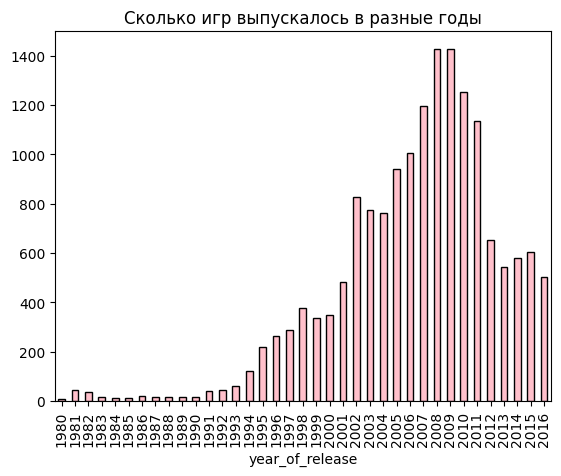

In [63]:
games_per_year.plot(kind = 'bar', color = 'pink', edgecolor = 'black')
plt.title('Сколько игр выпускалось в разные годы', fontsize=12)
plt.show()

Изучая этот график, можно сделать вывод, что видеоигры стали популярны в тот момент, когда пк и приставки стали доступны большему количеству людей.

**Теперь посмотрю, как менялись продажи по платформам. Необходимо выбрать платформы с наибольшими суммарными продажами.**

In [64]:
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending = False)
platform_sales

,total_sales
platform,
PS2,1255.77
X360,971.42
PS3,939.65
Wii,907.51
DS,806.12
PS,730.86
GBA,317.85
PS4,314.14
PSP,294.05


**Выберу 5 самых популярных платформ**

In [65]:
top_5_platforms = platform_sales.head(5).index
top_5_platforms

Index(['PS2', 'X360', 'PS3', 'Wii', 'DS'], dtype='object', name='platform')

In [66]:
df_top_platforms = df_filtered[df_filtered['platform'].isin(top_5_platforms)]
df_top_platforms

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8,E,82.54
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8,E,32.77
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89,8,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58,6,E,28.91
...,...,...,...,...,...,...,...,...,...,...,...,...
16700,Mezase!! Tsuri Master DS,DS,2009,Sports,0.00,0.00,0.01,0.00,-1,-1,unknown,0.01
16704,Plushees,DS,2008,Simulation,0.01,0.00,0.00,0.00,-1,-1,E,0.01
16709,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,0.00,0.00,0.00,0.00,-1,-1,unknown,0.00
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,-1,-1,unknown,0.01


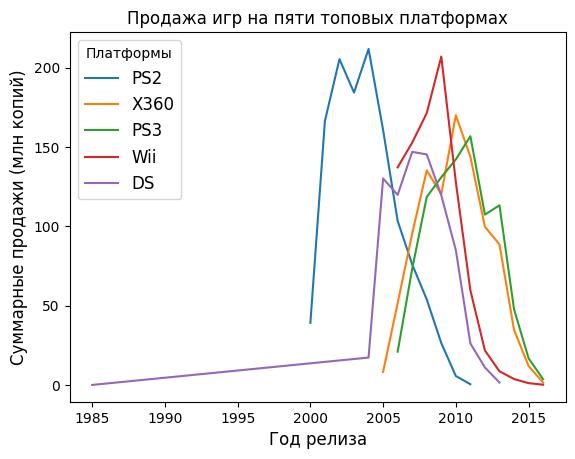

In [67]:
for platform in top_5_platforms:
    df_platform = df_top_platforms[df_top_platforms['platform'] == platform]
    platform_sales_per_year = df_platform.groupby('year_of_release')['total_sales'].sum()
    plt.plot(platform_sales_per_year.index, platform_sales_per_year.values, label = platform)

plt.title('Продажа игр на пяти топовых платформах', fontsize = 12)
plt.xlabel('Год релиза', fontsize=12)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=12)
plt.legend(title='Платформы', fontsize=12)
plt.show()

Смотря на этот график, можно сделать вывод, что в среднем консоль активно используется +- 10 лет. Потом выходит новая модель, которая мощнее, быстрее, функциональнее. Например, PS2 и PS3. У DS немного странный график. Может быть, он такой, потому что до 2004 года было мало данных о суммарных продажах.

**Теперь необходимо выбрать актуальный период. На основании предыдущего графика я выберу период с 2007 по 2016 год.**

In [68]:
df_actual = df[(df['year_of_release'] >= 2007) & (df['year_of_release'] <= 2016)]
df_actual

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8,E,32.77
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87,8,E,28.32
13,Wii Fit,Wii,2007,Sports,8.92,8.03,3.60,2.15,80,7,E,22.70
14,Kinect Adventures!,X360,2010,Misc,15.00,4.89,0.24,1.69,61,6,E,21.82
...,...,...,...,...,...,...,...,...,...,...,...,...
16707,Aiyoku no Eustia,PSV,2014,Misc,0.00,0.00,0.01,0.00,-1,-1,unknown,0.01
16709,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,0.00,0.00,0.00,0.00,-1,-1,unknown,0.00
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,-1,-1,unknown,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,-1,-1,unknown,0.01


**Посмотрим какие платформы лидируют по суммарным продажам за актуальный период.**

In [69]:
top_5_platforms = df_actual.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(5).index
data_top_5 = [df_actual[df_actual['platform'] == platform]['total_sales'] for platform in top_5_platforms]
top_5_platforms

Index(['PS3', 'X360', 'Wii', 'DS', 'PS4'], dtype='object', name='platform')

**Построю график 'ящик с усами' для глобалтных продаж.По факту этот график - это аналогия графика плотности распределения**

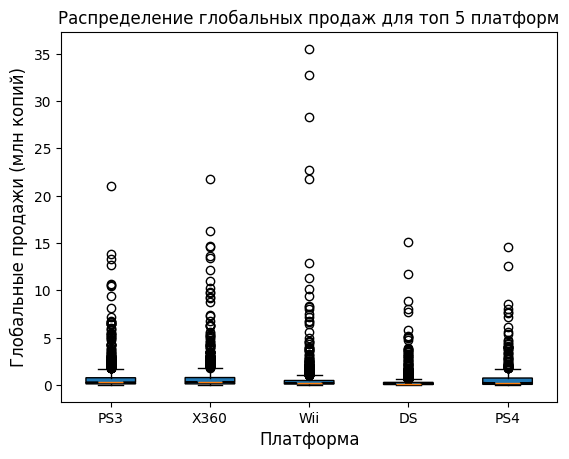

In [70]:
plt.boxplot(data_top_5, labels=top_5_platforms, patch_artist=True, notch=True, vert=True)
plt.title('Распределение глобальных продаж для топ 5 платформ', fontsize=12)
plt.xlabel('Платформа', fontsize=12)
plt.ylabel('Глобальные продажи (млн копий)', fontsize=12)
plt.show()

**Теперь добавлю диапозон, чтобы лучше рассмотреть детали графика.**

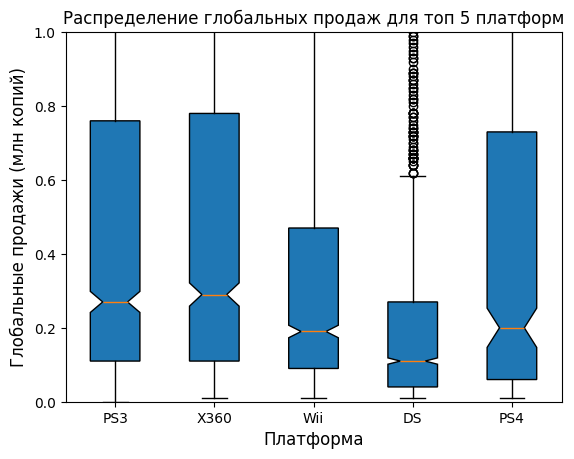

In [71]:
plt.boxplot(data_top_5, labels=top_5_platforms, patch_artist=True, notch=True, vert=True)
plt.title('Распределение глобальных продаж для топ 5 платформ', fontsize=12)
plt.xlabel('Платформа', fontsize=12)
plt.ylabel('Глобальные продажи (млн копий)', fontsize=12)
plt.ylim(0, 1) #Устанавливаю диапозон, чтобы лучше рассмотреть детали
plt.show()

**Горизантальная оранжевая черта показывает среднее значение. Концы 'усов' определяются, как края значимой выборки. Хуже всего продавалась DS: от 0.1 до 0.6 млн копий. Медиана у самыз продаваемых платформ разбросана в значениях от 0.2 до 0.3 млн. копий.**

****

**Теперь надо посмотреть, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков.**

In [72]:
pop_platform = df_actual.groupby('platform')['total_sales'].sum().sort_values(ascending=False).idxmax()
platform_df  =df_actual[df_actual['platform'] == pop_platform]
platform_df

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97,8,M,21.05
34,Call of Duty: Black Ops II,PS3,2012,Shooter,4.99,5.73,0.65,2.42,83,5,M,13.79
37,Call of Duty: Modern Warfare 3,PS3,2011,Shooter,5.54,5.73,0.49,1.57,88,3,M,13.33
41,Call of Duty: Black Ops,PS3,2010,Shooter,5.99,4.37,0.48,1.79,88,6,M,12.63
54,Gran Turismo 5,PS3,2010,Racing,2.96,4.82,0.81,2.11,84,7,E,10.70
...,...,...,...,...,...,...,...,...,...,...,...,...
16639,WSC REAL 09: World Snooker Championship,PS3,2009,Sports,0.00,0.01,0.00,0.00,-1,-1,unknown,0.01
16674,Tsukigime Ranko's Longest Day,PS3,2014,Action,0.00,0.01,0.00,0.00,-1,-1,unknown,0.01
16676,G1 Jockey 4 2008,PS3,2008,Sports,0.00,0.00,0.00,0.00,-1,-1,unknown,0.00
16691,Dynasty Warriors: Eiketsuden,PS3,2016,Action,0.00,0.00,0.01,0.00,-1,-1,unknown,0.01


**Корреляция между продажами и  оценками**

In [73]:
platform_df[['critic_score', 'user_score', 'total_sales']].corr()

,critic_score,user_score,total_sales
critic_score,1.000000,0.818734,0.352115
user_score,0.818734,1.000000,0.269450
total_sales,0.352115,0.269450,1.000000


**Теперь посторою диаграмму рассеивания**

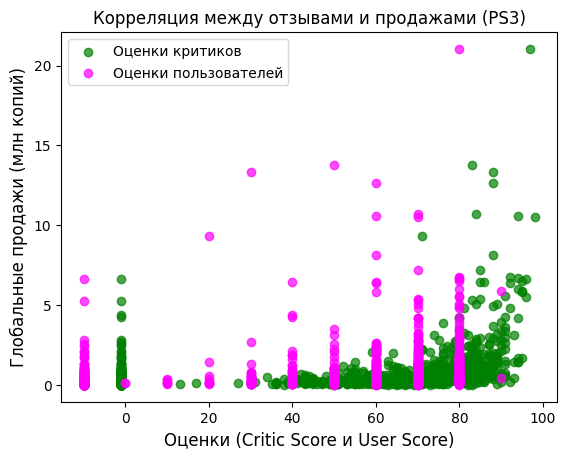

In [74]:
plt.scatter(platform_df['critic_score'], platform_df['total_sales'], alpha=0.7, label='Оценки критиков', color='green')
plt.scatter(platform_df['user_score'] * 10, platform_df['total_sales'], alpha=0.7, label='Оценки пользователей', color='magenta')
plt.title(f'Корреляция между отзывами и продажами ({pop_platform})', fontsize=12)
plt.xlabel('Оценки (Critic Score и User Score)', fontsize=12)
plt.ylabel('Глобальные продажи (млн копий)', fontsize=12)
plt.legend()
plt.show()

**Какие выводы можно сделать, смотря на этот график?**

1.   Выбросы показывают, что некоторые игры продаются хорошо вне зависимости от отзывов. Возможно, на это вляет известность франшизы или удачный маркетинг.
2.   Оценки критиков важнее, чем оценки юзеров, особенно на старте продаж.
3. Оценки пользователей образуют в основном образуют восходящий тренд, поэтому их мнение тоже важно для успеха игры.



**Распределение игр по жанрам**

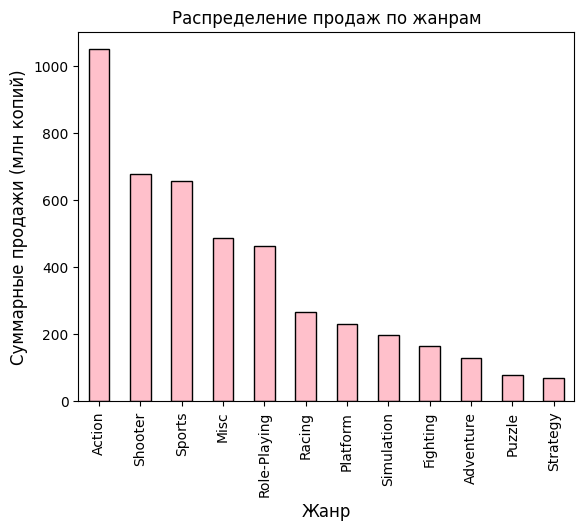

In [75]:
genre_sales = df_actual.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_sales.plot(kind='bar', color='pink', edgecolor='black')
plt.title('Распределение продаж по жанрам', fontsize=12)
plt.xlabel('Жанр', fontsize=12)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=12)
plt.show()

**Выводы, которые основывваются на этом графике:**

1.   Самые прибыльные игры: action, shooter, rpg. Причина этому, что эти жанры отлично подходят консолям, так как поддерживается высокий fps, качество графики, удобное управление с джойстика.
2.   Причина, по которой жанры puzzle, strategy наименее популярны - в играх этого жанра необходимо думать. Но для большая часть пользователей играет, чтобы рассластбиться. Следовательно, у этого жанра ограниченная аудитория.



****

**Перейду к следующему этапу анализа датасета. Необходимо составить портрет пользователя в каждом регионе.**

**Найду пять самых популярных платформ в каждом регионе. Для этого посчитаю продажи по платформам для каждого региона, используя группировку.**

In [76]:
na_platform_sales = df_actual.groupby('platform')['na_sales'].sum().sort_values(ascending=False)
eu_platform_sales = df_actual.groupby('platform')['eu_sales'].sum().sort_values(ascending=False)
jp_platform_sales = df_actual.groupby('platform')['jp_sales'].sum().sort_values(ascending=False)
top_5_na = na_platform_sales.head(5)
top_5_eu = eu_platform_sales.head(5)
top_5_jp = jp_platform_sales.head(5)

In [77]:
top_5_na

,na_sales
platform,
X360,553.68
Wii,416.01
PS3,381.29
DS,273.98
PS4,108.74


In [78]:
top_5_eu

,eu_sales
platform,
PS3,319.83
X360,257.05
Wii,214.70
PS4,141.09
DS,119.92


In [79]:
top_5_jp

,jp_sales
platform,
DS,102.93
3DS,100.62
PS3,78.33
PSP,66.24
Wii,59.13


**Теперь визуализирую**

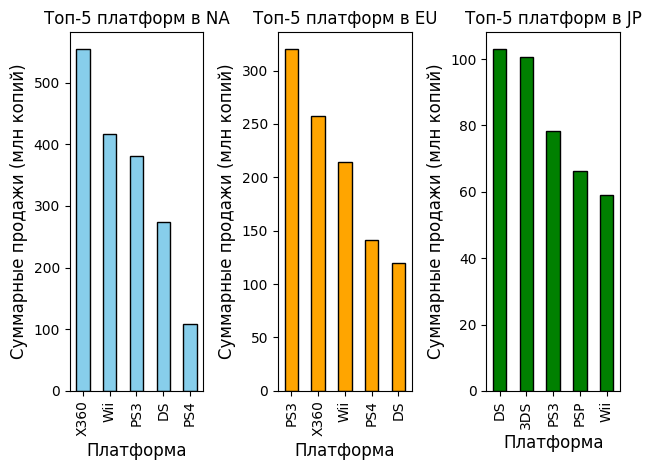

In [81]:
plt.subplot(1, 3, 1)
top_5_na.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Топ-5 платформ в NA', fontsize=12)
plt.xlabel('Платформа', fontsize=12)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=12)

plt.subplot(1, 3, 2)
top_5_eu.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Топ-5 платформ в EU', fontsize=12)
plt.xlabel('Платформа', fontsize=12)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=12)

plt.subplot(1, 3, 3)
top_5_jp.plot(kind='bar', color='green', edgecolor='black')
plt.title('Топ-5 платформ в JP', fontsize=12)
plt.xlabel('Платформа', fontsize=12)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=12)

plt.tight_layout()
plt.show()

**Выводы:**

1.   В Северной Америке и Японии наиболее популярны платформы региональных компаний(Xbox, Sony, Nintendo)
2.   В Европе ситуация похожа на Северную Америку.



**Теперь найду пять самых популярных жанров в каждом регионе**

In [82]:
na_genre_sales = df_actual.groupby('genre')['na_sales'].sum().sort_values(ascending=False)
eu_genre_sales = df_actual.groupby('genre')['eu_sales'].sum().sort_values(ascending=False)
jp_genre_sales = df_actual.groupby('genre')['jp_sales'].sum().sort_values(ascending=False)
top_5_na_genres = na_genre_sales.head(5)
top_5_eu_genres = eu_genre_sales.head(5)
top_5_jp_genres = jp_genre_sales.head(5)

In [83]:
top_5_na_genres

,na_sales
genre,
Action,492.17
Shooter,350.11
Sports,323.86
Misc,259.16
Role-Playing,175.41


In [84]:
top_5_eu_genres

,eu_sales
genre,
Action,335.67
Shooter,230.16
Sports,211.49
Misc,127.62
Racing,104.63


In [85]:
top_5_jp_genres

,jp_sales
genre,
Role-Playing,150.55
Action,96.29
Misc,48.79
Sports,40.28
Adventure,26.91


**Визуализирую**

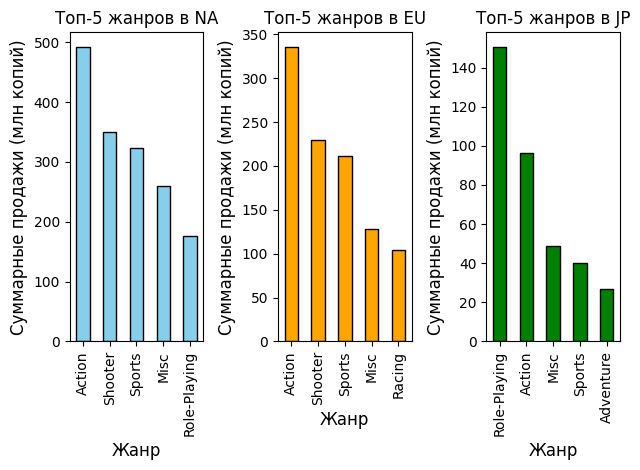

In [86]:
plt.subplot(1, 3, 1)
top_5_na_genres.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Топ-5 жанров в NA', fontsize=12)
plt.xlabel('Жанр', fontsize=12)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=12)

plt.subplot(1, 3, 2)
top_5_eu_genres.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Топ-5 жанров в EU', fontsize=12)
plt.xlabel('Жанр', fontsize=12)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=12)

plt.subplot(1, 3, 3)
top_5_jp_genres.plot(kind='bar', color='green', edgecolor='black')
plt.title('Топ-5 жанров в JP', fontsize=12)
plt.xlabel('Жанр', fontsize=12)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=12)

plt.tight_layout()
plt.show()

**Выводы:**

1.   В Северной Америке и Европе наиболее популярны быстрые, соревновательные жанры(Action, Shooter, Sports, и Role-Playing). Также важна популярность франшизы.
2.   В Японии лидирует rpg. Жанр adventure более наиболее популярен в Японии, чем в других странах.



**Влияет ли рейтинг ESRB на продажи? Для этого рассчитаю продажи по возрастному рейтингу.**

In [87]:
na_rating_sales = df_actual.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
eu_rating_sales = df_actual.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
jp_rating_sales = df_actual.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)

In [88]:
na_rating_sales

,na_sales
rating,
E,663.99
M,546.55
T,371.32
E10+,287.61
unknown,253.75
EC,1.32
RP,0.00


In [89]:
eu_rating_sales

,eu_sales
rating,
E,393.08
M,385.86
T,217.89
unknown,208.50
E10+,162.75
RP,0.03
EC,0.00


In [90]:
jp_rating_sales

,jp_sales
rating,
unknown,244.77
E,95.06
T,74.74
M,41.09
E10+,31.91
EC,0.00
RP,0.00


**Визуализирую**

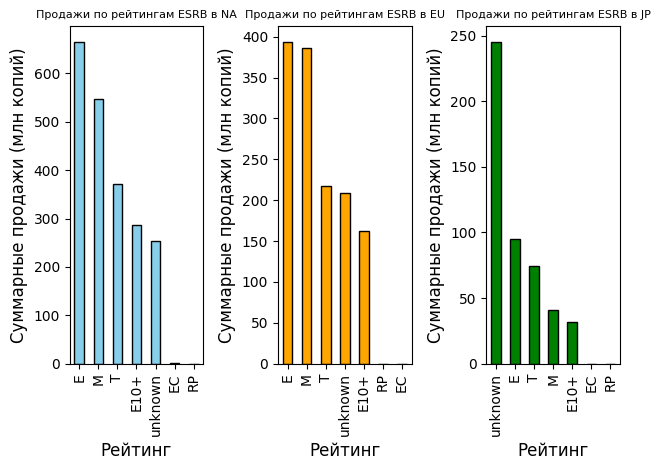

In [93]:
plt.subplot(1, 3, 1)
na_rating_sales.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Продажи по рейтингам ESRB в NA', fontsize=8)
plt.xlabel('Рейтинг', fontsize=12)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=12)

plt.subplot(1, 3, 2)
eu_rating_sales.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Продажи по рейтингам ESRB в EU', fontsize=8)
plt.xlabel('Рейтинг', fontsize=12)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=12)

plt.subplot(1, 3, 3)
jp_rating_sales.plot(kind='bar', color='green', edgecolor='black')
plt.title('Продажи по рейтингам ESRB в JP', fontsize=8)
plt.xlabel('Рейтинг', fontsize=12)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=12)

plt.tight_layout()
plt.show()

**Выводы:**

1.   В Северной Америке и Европе игры для всех возрастов и для взрослых(E, M соответственно) популярнее всего.
2.   В Японии рейтинг ESRB мало вляет на продажу игры, потому что в подавляющей части игры релизят вообще без рейтинга.



****

**Выводы:**

1.   Важно учитывать, что рынок в Северной Америке и Европе похож
2.   Для Японии следует выпускать игры на платформе Nintendo
3. Для Северной Америки и Европы игры продаются лучше, если у них рейтинг ESRB E. Это делает игру более доступной для широкой аудитории.
4. Очень важны оценки критиков. Также важен маркетинг и популярность франшизы. Эти факторы могут создать положительную динамику на старте продаж.

